# 10 — Indicadores de congestión
| indicador | fórmula | se lee |
|---|---|---|
| tasa de resolución | resueltas ÷ ingresadas | < 1: entra más de lo que sale, la mora crece |
| tasa de congestión | atendidas ÷ resueltas | 3 = por cada causa resuelta se gestionaron 3 |
| tasa de pendencia | pendientes_fin ÷ atendidas | parte de la carga que pasa al año siguiente |
| duración estimada | pendientes_fin ÷ resueltas × 365 | días para vaciar el stock al ritmo actual |

`ingresadas` = suma de **todas** las formas de ingreso (no solo `nuevas_ingresadas`).
`pct_resueltas` del anuario es resueltas ÷ atendidas: **no** es la tasa de resolución.

In [1]:
%run -i modulos/comun.ipynb
%run -i modulos/nulos.ipynb
%run -i modulos/metricas.ipynb
import matplotlib.pyplot as plt

OUT_FEATURES = CURATED / "features"
OUT_EDA = CURATED / "eda"
OUT_FEATURES.mkdir(parents=True, exist_ok=True)
OUT_EDA.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(PROCESSED / "analitico" / "dataset_analitico_interno.parquet")
df["estado_gestion"] = clasificar_dinamica_procesal(df)
df_ind = calcular_indicadores_congestion(df)
print(len(df_ind.columns) - len(df.columns), "columnas nuevas:", list(df_ind.columns[len(df.columns):]))

12 columnas nuevas: ['ingresos_totales', 'tasa_resolucion', 'tasa_resolucion_solo_nuevas', 'tasa_congestion', 'tasa_pendencia', 'duracion_estimada_dias', 'acumulacion_neta_anual', 'flag_acumula_mora', 'flag_sin_resolucion_anual', 'flag_sin_movimiento', 'atendidas_por_item_personal', 'atendidas_por_juzgado_territorio']


## Control: la suma de formas de ingreso reproduce atendidas − pendientes_inicio
Obligatorio en el estrato `proceso`. Los cuadros penales publican otras formas de ingreso y no
cierran la identidad: por eso los indicadores CEJA se reportan solo sobre procesos no penales.

In [2]:
es_proceso = df_ind["tipo_elemento_analitico"] == "proceso"
descuadres = verificar_identidad_ingresos(df_ind, mascara=es_proceso)
assert descuadres.empty, "La suma de formas de ingreso no reproduce la identidad en " + str(len(descuadres)) + " filas"
fuera = verificar_identidad_ingresos(df_ind, mascara=~es_proceso)
print("identidad OK en procesos; filas penales que no la cierran:", len(fuera))

identidad OK en procesos; filas penales que no la cierran: 89


In [3]:
df_ind.to_parquet(OUT_FEATURES / "dataset_analitico_indicadores.parquet", index=False)
df_ind.to_csv(OUT_FEATURES / "dataset_analitico_indicadores.csv", index=False, encoding="utf-8")
assert len(df_ind) == 1997

## Banderas sobre los procesos

In [4]:
proc = df_ind[df_ind["tipo_elemento_analitico"] == "proceso"]
for bandera in ["flag_acumula_mora", "flag_sin_resolucion_anual", "flag_sin_movimiento"]:
    n = int(proc[bandera].sum())
    print(bandera, n, "procesos ({:.1%})".format(n / len(proc)))

flag_acumula_mora 747 procesos (45.1%)
flag_sin_resolucion_anual 118 procesos (7.1%)
flag_sin_movimiento 415 procesos (25.1%)


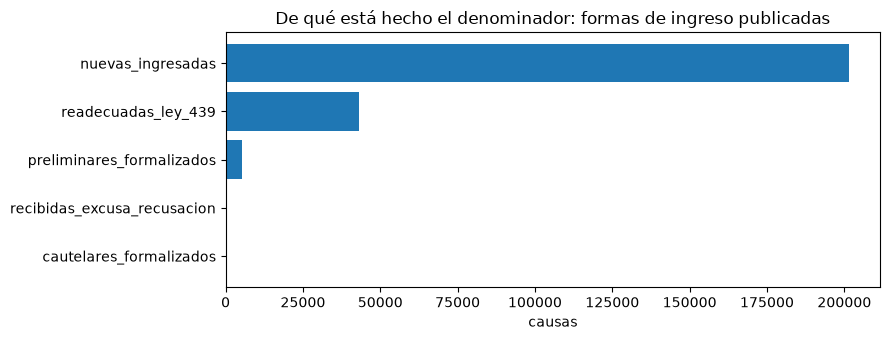

In [5]:
aporte = proc[[c for c in COLUMNAS_INGRESOS if c in proc.columns]].fillna(0).sum()
aporte = aporte[aporte > 0].sort_values()
plt.figure(figsize=(9, 3.5))
plt.barh(aporte.index, aporte.values, color="tab:blue")
plt.title("De qué está hecho el denominador: formas de ingreso publicadas")
plt.xlabel("causas")
plt.tight_layout()
plt.show()

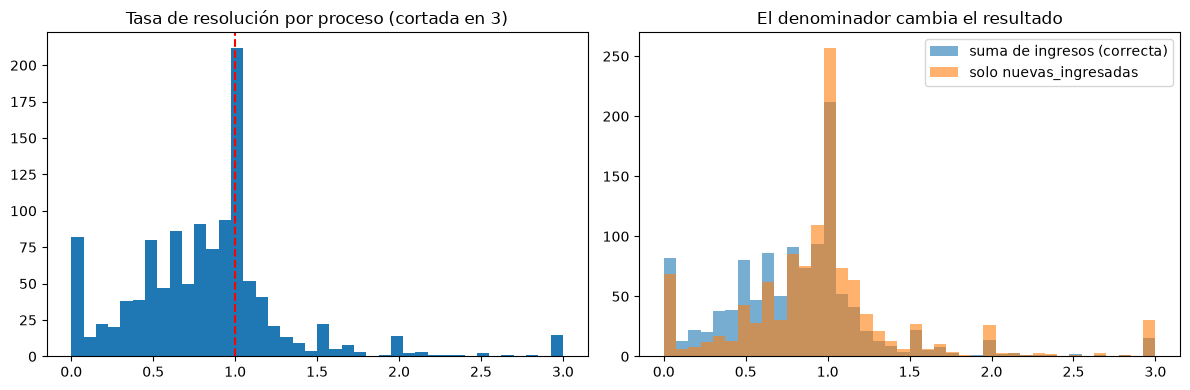

In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
ejes[0].hist(proc["tasa_resolucion"].dropna().clip(upper=3), bins=40, color="tab:blue")
ejes[0].axvline(1, color="red", linestyle="--")
ejes[0].set_title("Tasa de resolución por proceso (cortada en 3)")
ejes[1].hist(proc["tasa_resolucion"].dropna().clip(upper=3), bins=40, alpha=0.6, label="suma de ingresos (correcta)")
ejes[1].hist(proc["tasa_resolucion_solo_nuevas"].dropna().clip(upper=3), bins=40, alpha=0.6, label="solo nuevas_ingresadas")
ejes[1].legend()
ejes[1].set_title("El denominador cambia el resultado")
plt.tight_layout()
plt.show()

## Resumen por materia
Mediana = proceso típico. Ponderada = el sistema en conjunto (totales ÷ totales).

In [7]:
validos = proc[proc["resueltas"].notnull() & (proc["atendidas"] > 0)]
resumen_mat = validos.groupby("materia_homologada").agg(
    total_procesos=("tipo_proceso", "count"),
    ingresos_total=("ingresos_totales", "sum"),
    atendidas_total=("atendidas", "sum"),
    resueltas_total=("resueltas", "sum"),
    pendientes_total=("pendientes_fin", "sum"),
    cr_mediana=("tasa_resolucion", "median"),
    congestion_mediana=("tasa_congestion", "median"),
    duracion_dias_mediana=("duracion_estimada_dias", "median"),
).reset_index()
resumen_mat["clearance_rate_ponderado"] = resumen_mat["resueltas_total"] / resumen_mat["ingresos_total"].replace(0, pd.NA)
resumen_mat["tasa_congestion_ponderada"] = resumen_mat["atendidas_total"] / resumen_mat["resueltas_total"].replace(0, pd.NA)
resumen_mat["duracion_dias_ponderada"] = (resumen_mat["pendientes_total"] / resumen_mat["resueltas_total"].replace(0, pd.NA)) * 365
resumen_mat.to_csv(OUT_EDA / "resumen_indicadores_materia.csv", index=False, encoding="utf-8")
resumen_mat

,materia_homologada,total_procesos,ingresos_total,atendidas_total,resueltas_total,pendientes_total,cr_mediana,congestion_mediana,duracion_dias_mediana,clearance_rate_ponderado,tasa_congestion_ponderada,duracion_dias_ponderada
0,Partido Administrativo Coactivo Fiscal y Tribu...,30,2012.0,13249,2671,10368,1.000000,2.869646,582.479167,1.327535,4.960314,1416.817671
1,Partido de Trabajo y Seguridad Social,152,24073.0,51342,23441,27901,1.000000,2.000000,365.000000,0.973747,2.190265,434.446696
2,Público Civil y Comercial,384,136874.0,136874,94769,42105,0.573815,1.647339,236.278711,0.692381,1.444291,162.166162
3,Público Niñez y Adolescencia,325,9546.0,13524,9106,4418,0.986842,1.309211,112.861842,0.953907,1.485175,177.088733
4,Público de Familia,349,78366.0,120483,79210,41273,1.000000,1.500000,182.500000,1.01077,1.521058,190.186151


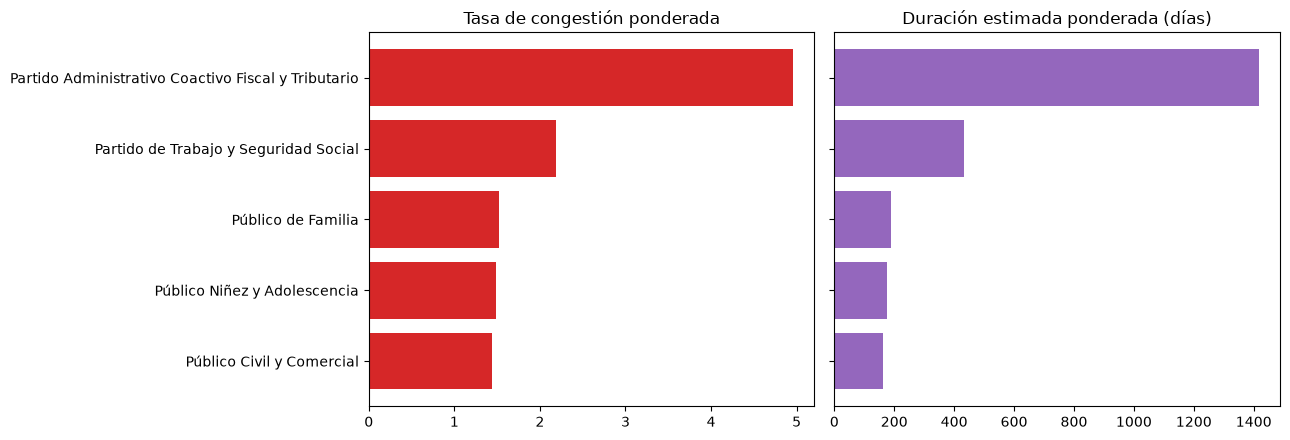

In [8]:
orden = resumen_mat.sort_values("tasa_congestion_ponderada")
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
ejes[0].barh(orden["materia_homologada"], orden["tasa_congestion_ponderada"].astype(float), color="tab:red")
ejes[0].set_title("Tasa de congestión ponderada")
ejes[1].barh(orden["materia_homologada"], orden["duracion_dias_ponderada"].astype(float), color="tab:purple")
ejes[1].set_title("Duración estimada ponderada (días)")
ejes[1].set_yticklabels([])
plt.tight_layout()
plt.show()